# Induction Head Distribution Map

This notebook builds a top-32 token/concept induction-head distribution map for `Llama-3.1-8B` from the cached causal head orderings in `cache/head_orderings` and the cached causal copying scores in `cache/causal_scores`.

The figure shows each top-ranked head at its `(layer, head_idx)` position, with token heads plotted as blue circles and concept heads plotted as red diamonds.


In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "serif",
    }
)

MODEL_NAME = "Llama-3.1-8B"
DISPLAY_NAME = MODEL_NAME
TOP_K = 32
CAUSAL_N = 1024
SEQUENCE_LEN = 30
SAVE_FIGURE = False
FIGURE_NAME = (
    f"{MODEL_NAME.lower().replace('.', '_')}_top{TOP_K}_induction_distribution_map.png"
)

CATEGORY_STYLES = {
    "Token": {"label": "Token", "marker": "o", "color": "#6C8FEA", "x_offset": -0.12},
    "Concept": {
        "label": "Concept",
        "marker": "D",
        "color": "#D46A6A",
        "x_offset": 0.12,
    },
}

In [ ]:
def find_repo_root(start: Path) -> Path:
    candidates = []
    for candidate in (start, *start.parents):
        candidates.extend(
            [
                candidate,
                candidate / "dual-route-induction",
                candidate / "improbable-bigram-causality" / "dual-route-induction",
            ]
        )

    for candidate in candidates:
        if (candidate / "cache").exists() and (candidate / "scripts").exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not locate the dual-route-induction repo root from the current working directory."
    )


ROOT = find_repo_root(Path.cwd().resolve())
ROOT

WindowsPath('D:/uni/courses/S2026/CS_7180/Project/improbable-bigram-causality/dual-route-induction')

In [ ]:
def choose_existing_path(*paths: Path) -> Path:
    for path in paths:
        if path.exists():
            return path
    checked = "\n".join(str(path) for path in paths)
    raise FileNotFoundError(f"None of these paths exist:\n{checked}")


def ranking_path(score_type: str) -> Path:
    return choose_existing_path(
        ROOT / "cache" / "head_orderings" / MODEL_NAME / f"{score_type}_copying.json",
        ROOT
        / "cache"
        / "head_orderings"
        / MODEL_NAME
        / f"{score_type}_copying_len{SEQUENCE_LEN}_n{CAUSAL_N}.json",
    )


def causal_score_path(score_type: str) -> Path:
    return choose_existing_path(
        ROOT
        / "cache"
        / "causal_scores"
        / MODEL_NAME
        / f"{score_type}_copying_len{SEQUENCE_LEN}_n{CAUSAL_N}.json"
    )


def load_ranked_heads(path: Path) -> list[tuple[int, int]]:
    return [tuple(head) for head in json.loads(path.read_text())]


def load_scored_heads(path: Path) -> dict[tuple[int, int], float]:
    records = json.loads(path.read_text())
    return {(item["layer"], item["head_idx"]): float(item["score"]) for item in records}


def head_label(head: tuple[int, int]) -> str:
    return f"{head[0]}.{head[1]}"


def build_head_table(
    score_type: str, ranked_heads: list[tuple[int, int]], top_k: int = TOP_K
) -> pd.DataFrame:
    category = score_type.title()
    causal_scores = load_scored_heads(causal_score_path(score_type))
    rows = []
    for rank, (layer, head_idx) in enumerate(ranked_heads[:top_k], start=1):
        key = (layer, head_idx)
        rows.append(
            {
                "category": category,
                "rank": rank,
                "head": head_label(key),
                "layer": layer,
                "head_idx": head_idx,
                "causal_copying_score": causal_scores[key],
            }
        )
    return pd.DataFrame(rows)


token_ranking = load_ranked_heads(ranking_path("token"))
concept_ranking = load_ranked_heads(ranking_path("concept"))

NUM_LAYERS = max(layer for layer, _ in token_ranking + concept_ranking) + 1
NUM_HEADS = max(head_idx for _, head_idx in token_ranking + concept_ranking) + 1

token_heads = build_head_table("token", token_ranking)
concept_heads = build_head_table("concept", concept_ranking)
head_map = pd.concat([token_heads, concept_heads], ignore_index=True)
shared_heads = (
    head_map[head_map.duplicated(["layer", "head_idx"], keep=False)][
        ["layer", "head_idx"]
    ]
    .drop_duplicates()
    .sort_values(["layer", "head_idx"])
    .reset_index(drop=True)
)

In [ ]:
display(head_map.round({"causal_copying_score": 4}))

layer_counts = (
    head_map.groupby(["category", "layer"]).size().unstack(fill_value=0).astype(int)
)
display(layer_counts)

shared_labels = [
    head_label((int(row.layer), int(row.head_idx))) for row in shared_heads.itertuples()
]
print(
    f"Shared heads between the top-{TOP_K} token and concept rankings: "
    f"{', '.join(shared_labels) if shared_labels else 'None'}"
)

,category,rank,head,layer,head_idx,causal_copying_score
0,Token,1,15.30,15,30,0.0032
1,Token,2,16.23,16,23,0.0020
2,Token,3,31.24,31,24,0.0018
3,Token,4,20.23,20,23,0.0010
4,Token,5,15.28,15,28,0.0010
...,...,...,...,...,...,...
59,Concept,28,25.22,25,22,0.0001
60,Concept,29,15.21,15,21,0.0001
61,Concept,30,19.28,19,28,0.0001
62,Concept,31,21.15,21,15,0.0001


layer,1,2,6,7,9,10,11,13,14,15,...,21,23,24,25,26,27,28,29,30,31
category,,,,,,,,,,,,,,,,,,,,,
Concept,1,0,1,2,1,0,1,1,2,6,...,3,1,2,1,1,1,0,0,0,0
Token,0,1,0,0,0,1,0,0,0,4,...,1,0,0,1,0,2,2,2,4,6


Shared heads between the top-32 token and concept rankings: 15.1


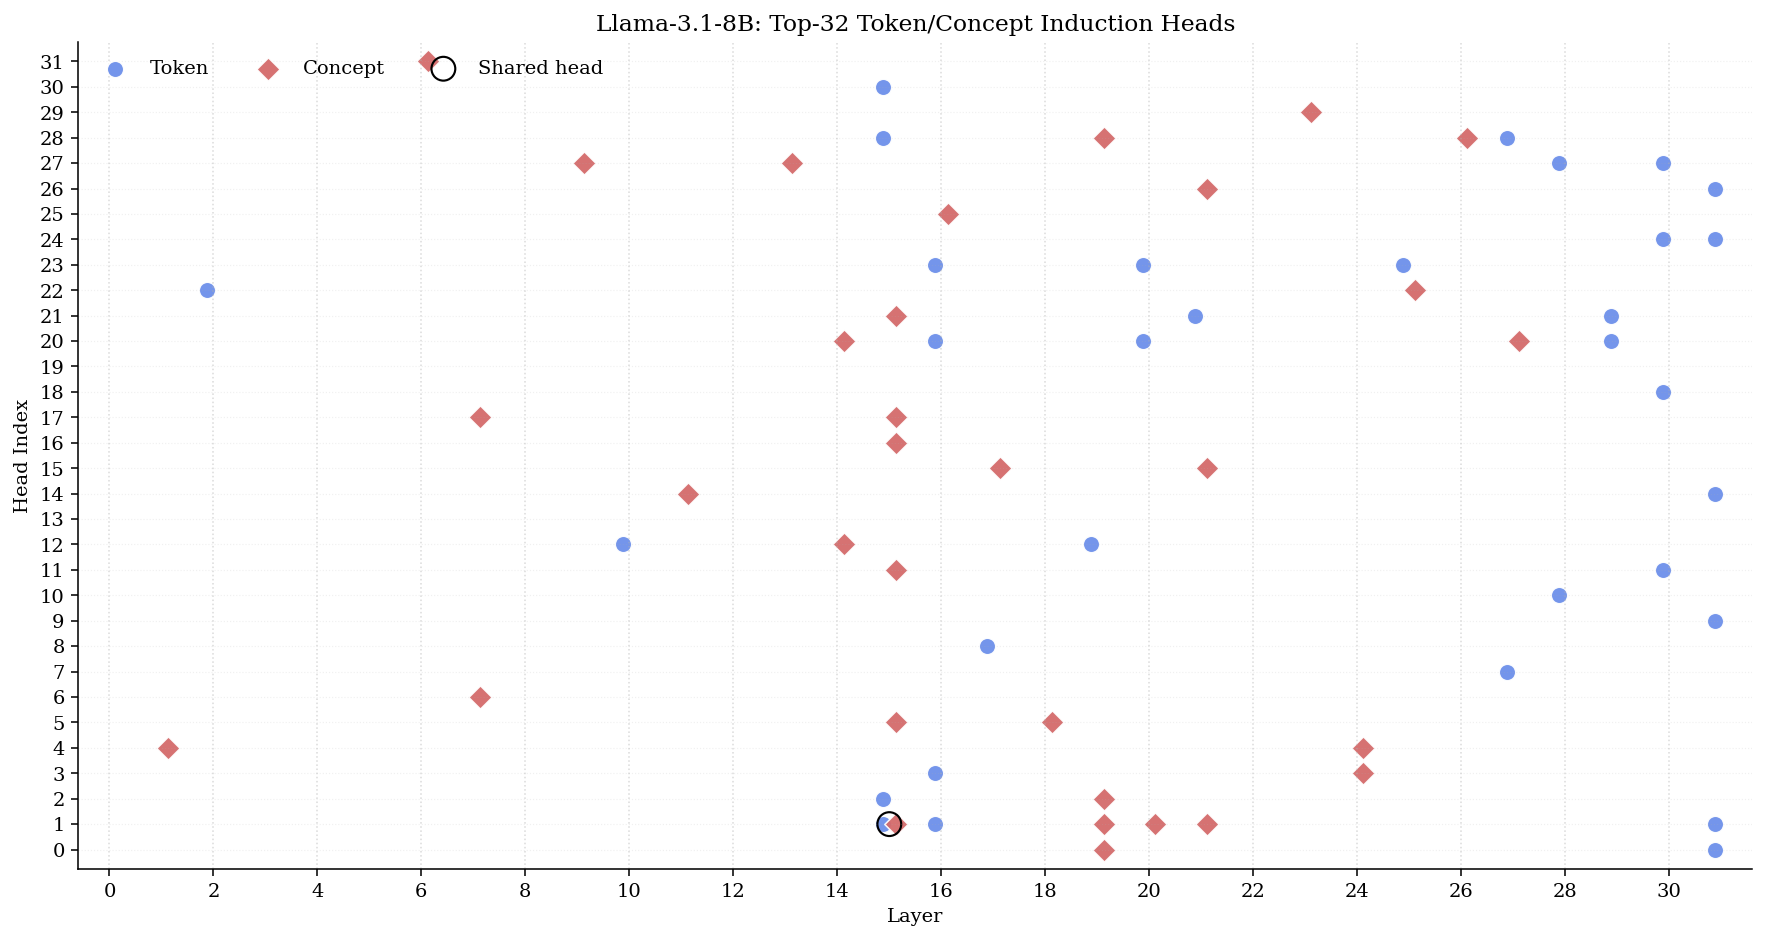

In [ ]:
def plot_distribution_map(ax, df: pd.DataFrame) -> None:
    for category, style in CATEGORY_STYLES.items():
        subset = df[df["category"] == category]
        ax.scatter(
            subset["layer"] + style["x_offset"],
            subset["head_idx"],
            s=72,
            marker=style["marker"],
            color=style["color"],
            edgecolors="white",
            linewidths=0.8,
            alpha=0.95,
            label=style["label"],
        )

    if not shared_heads.empty:
        ax.scatter(
            shared_heads["layer"],
            shared_heads["head_idx"],
            s=150,
            facecolors="none",
            edgecolors="black",
            linewidths=1.1,
            label="Shared head",
        )

    x_step = 2 if NUM_LAYERS <= 40 else 4
    ax.set_title(f"{DISPLAY_NAME}: Top-{TOP_K} Token/Concept Induction Heads")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Head Index")
    ax.set_xlim(-0.6, NUM_LAYERS - 0.4)
    ax.set_ylim(-0.75, NUM_HEADS - 0.25)
    ax.set_xticks(np.arange(0, NUM_LAYERS, x_step))
    ax.set_yticks(np.arange(NUM_HEADS))
    ax.grid(axis="x", linestyle=":", linewidth=0.8, alpha=0.45)
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.18)
    ax.legend(loc="upper left", frameon=False, ncols=3)
    ax.margins(x=0.02)


fig, ax = plt.subplots(figsize=(12.5, 6.6), constrained_layout=True)
plot_distribution_map(ax, head_map)

if SAVE_FIGURE:
    output_dir = ROOT / "figures"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / FIGURE_NAME
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {output_path}")

plt.show()